# Unified treatment of all our hypotheses:
# 1. Hypothesis: $Y = A Q B Q^t$, with $A = diag(\lambda)$, $B = diag(\phi)$, with SVD $Y = U S V^t$, 
# with $S = diag(\psi)$, and $Q$, $U$, $V$ all orthogonal. 
# Which of the following are true, as $d \rightarrow \infty$?
# 1.1 : $(Tr(Y))^2 / Tr(Y^2) \rightarrow \nu(\psi)$
# 1.2 : $Tr(Y) / Tr(S) \rightarrow 1$
# 1.3 : $Tr(Y^2) / Tr(S^2) \rightarrow 1$
# 1.4 : Does uniform / Cauchy / Pareto make any difference?
# 1.5 : If $\lambda \sim Pareto(\alpha)$, and $\phi \sim Pareto(\beta)$, 
# does convergence depend on $\alpha$, $\beta$?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 1 (i) Uniform

In [2]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_uniform"] = True
this_config["B_diagonal"] = True
this_config["B_uniform"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is uniform
generating B
B is diagonal
B is uniform
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calc

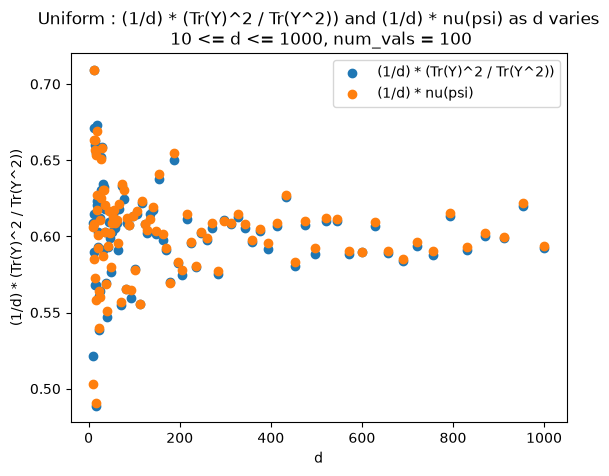

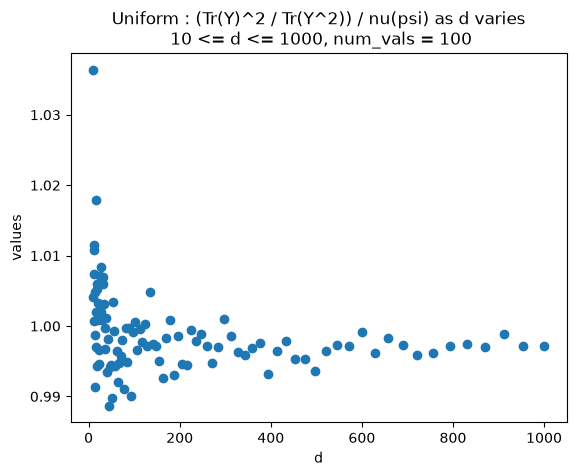

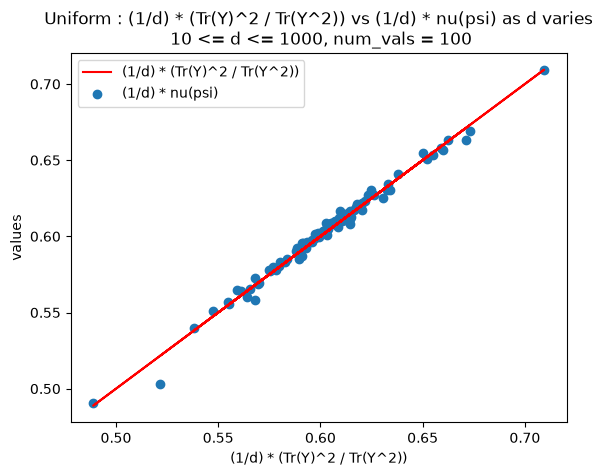

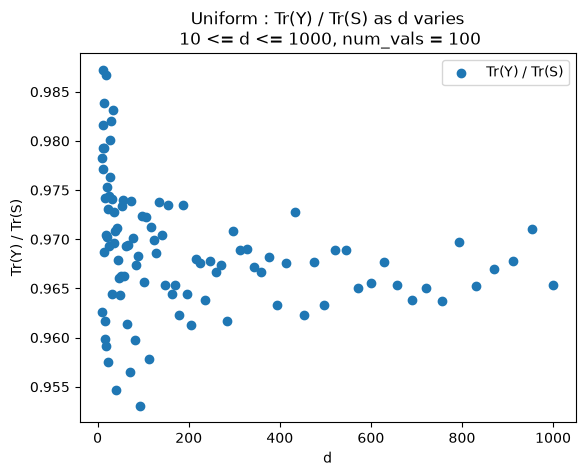

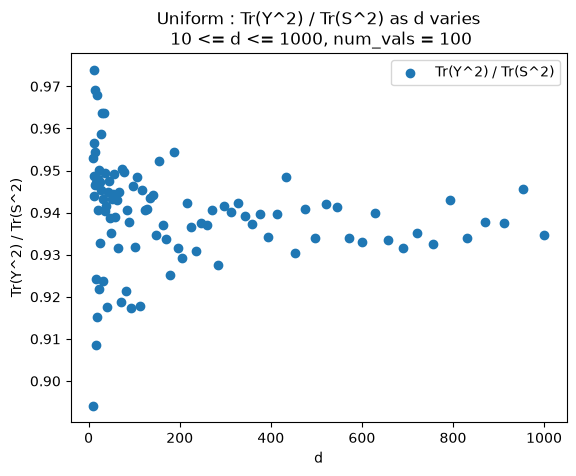

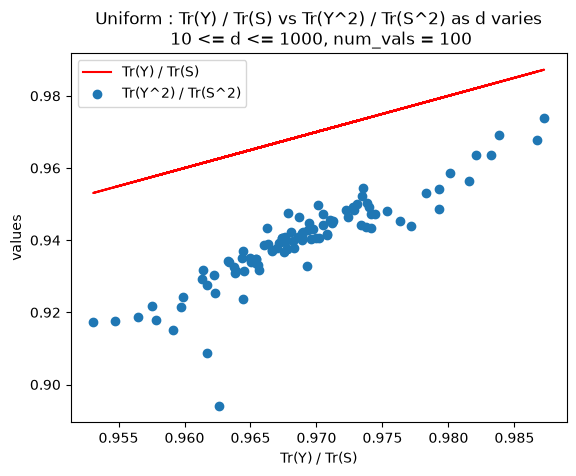

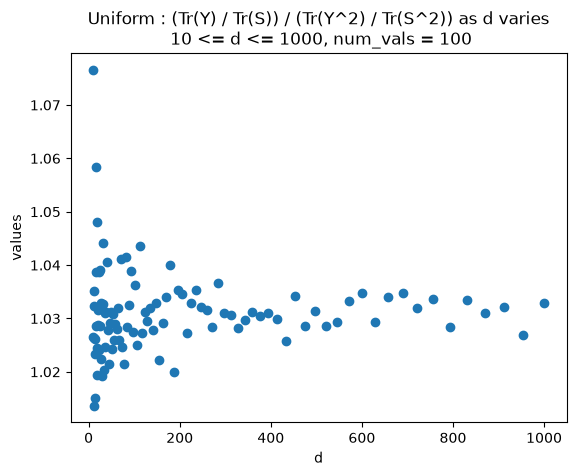

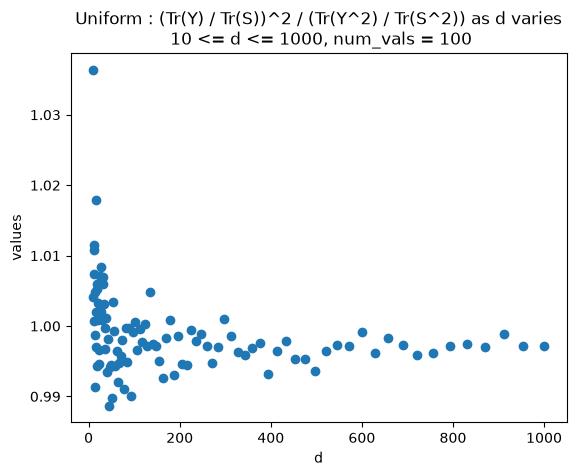

In [3]:
pp.plot_one(xx, "Uniform")

# (ii) Cauchy

In [5]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_cauchy"] = True
this_config["B_diagonal"] = True
this_config["B_cauchy"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.]
[1.]
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Cauchy
generating B
B is diagonal
B is Cauchy
A.shape =  (10, 10)
Q.shape =  (10, 10)
B.shape =  (10, 10)
Qt.shape =  (10, 10)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculat

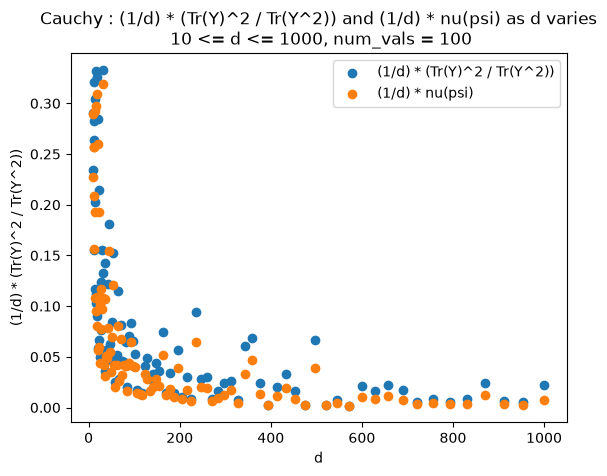

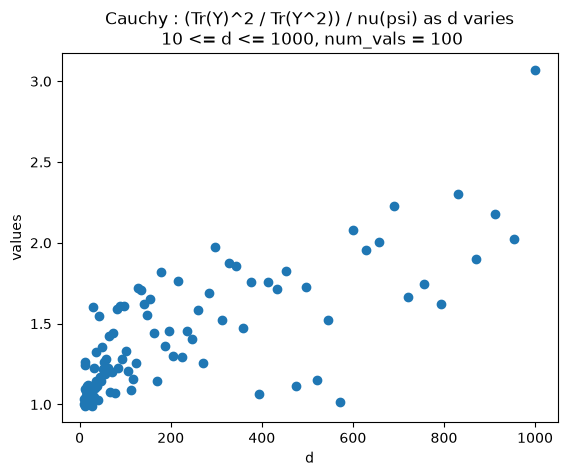

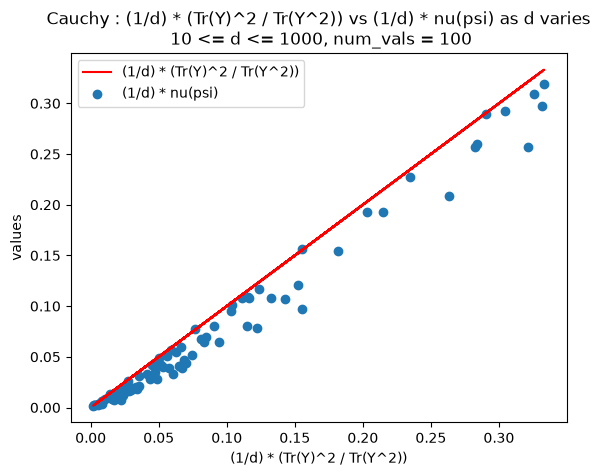

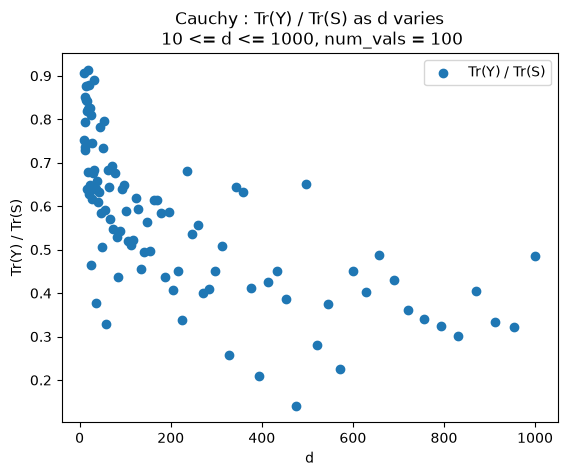

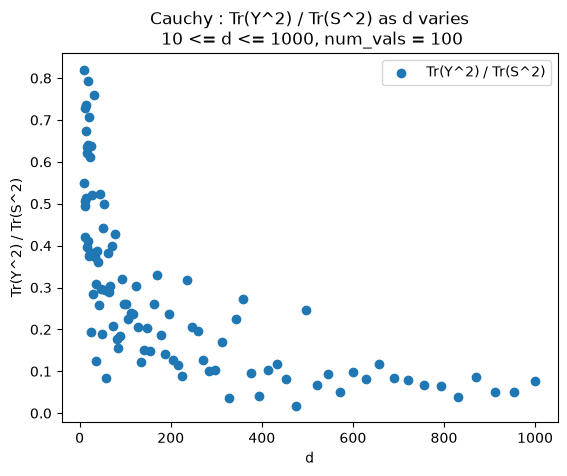

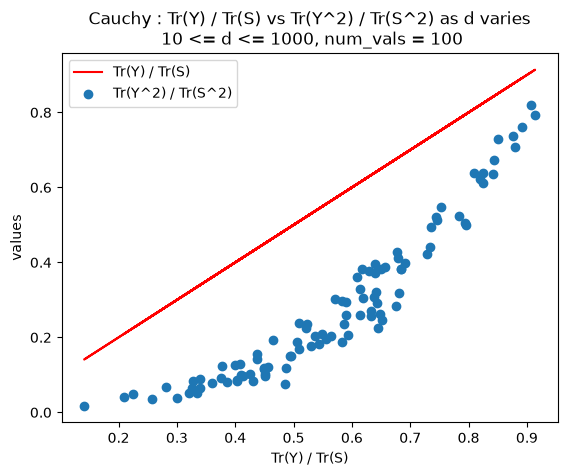

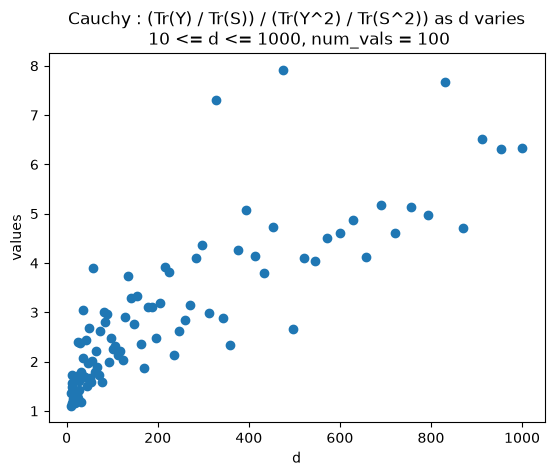

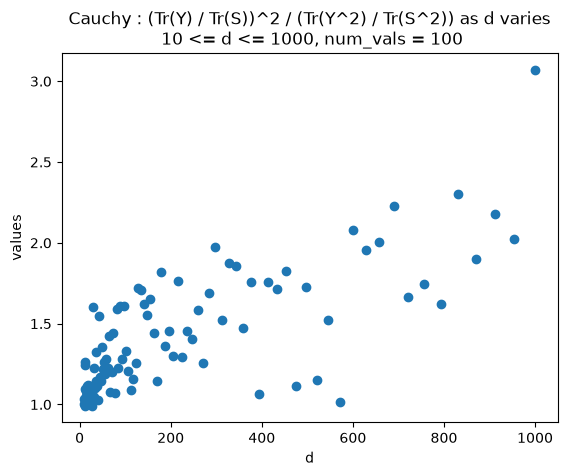

In [6]:
pp.plot_one(xx, "Cauchy")

# (iii) Pareto, fix alpha, beta, allow d to vary

In [8]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 2.0
B_beta = 3.0
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]
[3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3.]
generating A
A is diagonal
A is

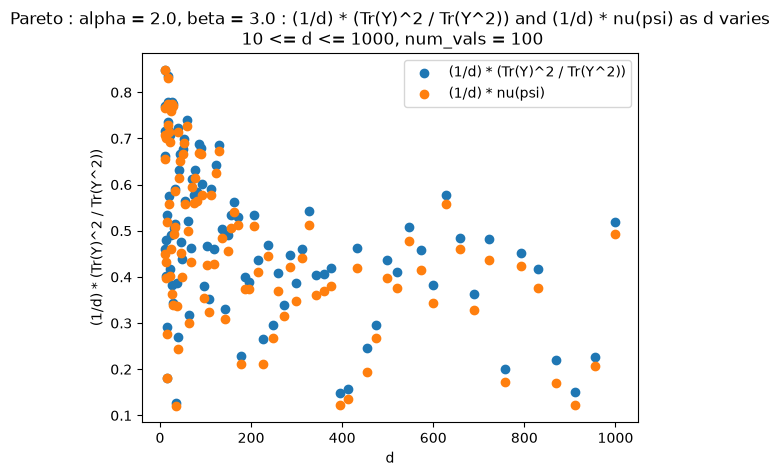

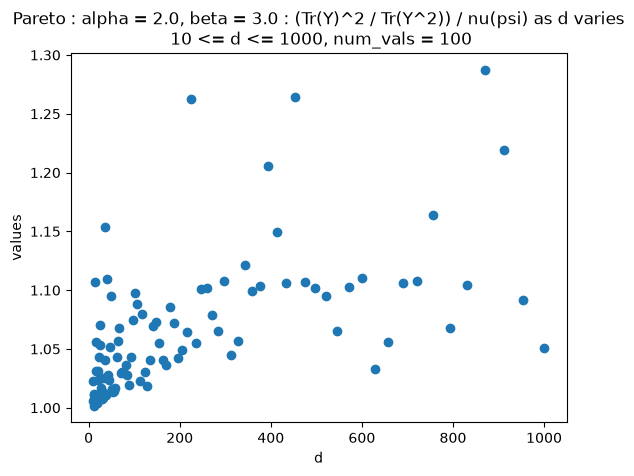

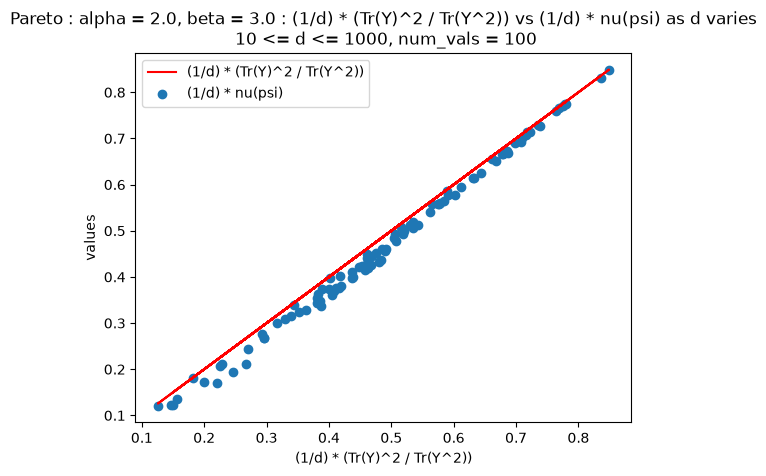

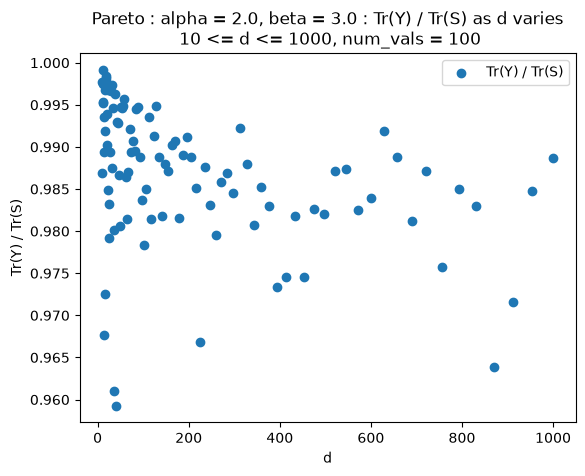

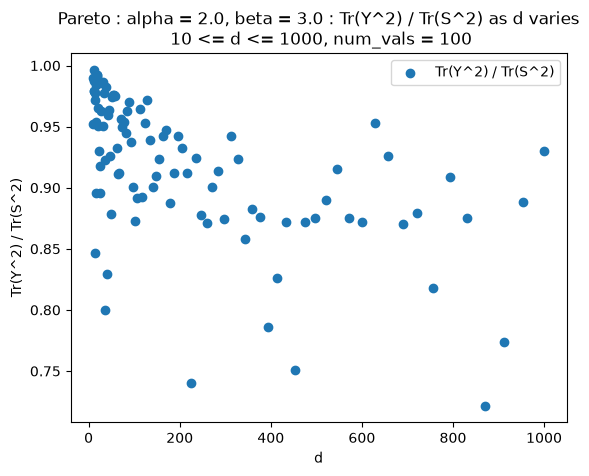

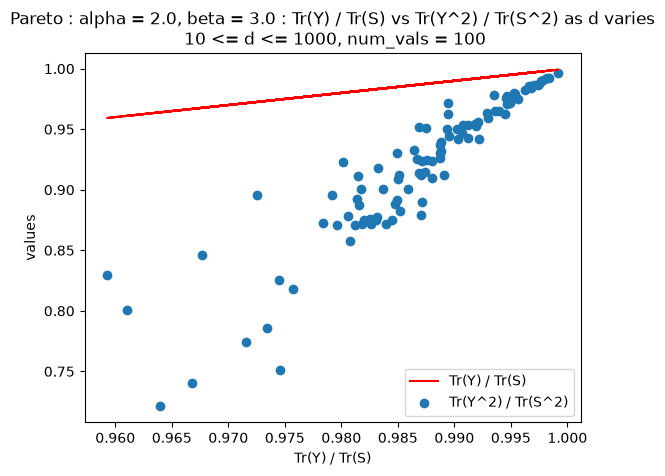

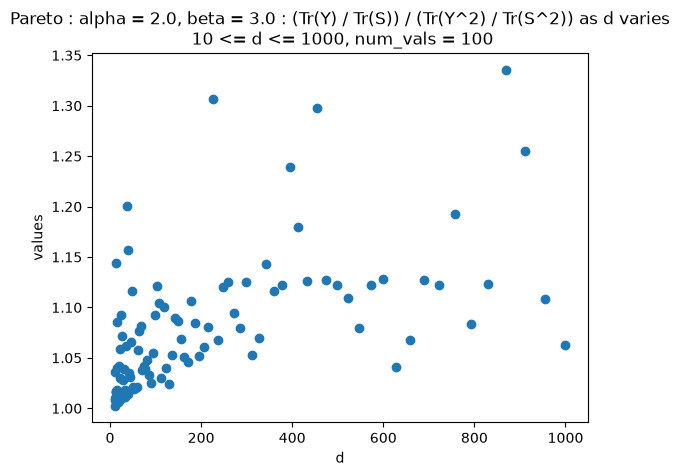

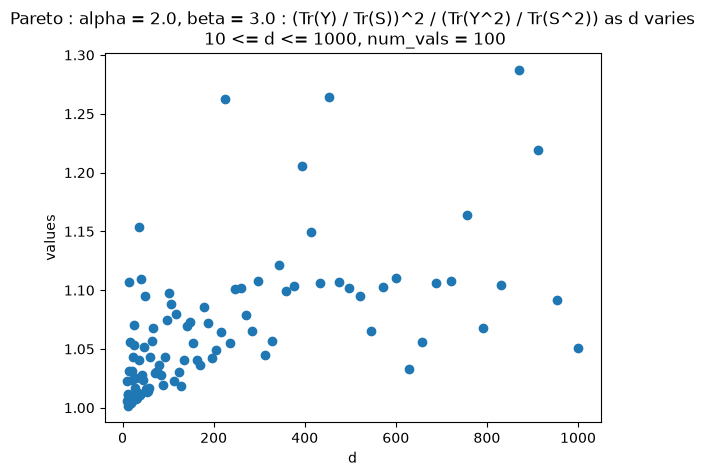

In [9]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

# More Pareto

In [10]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 10
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 1.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 

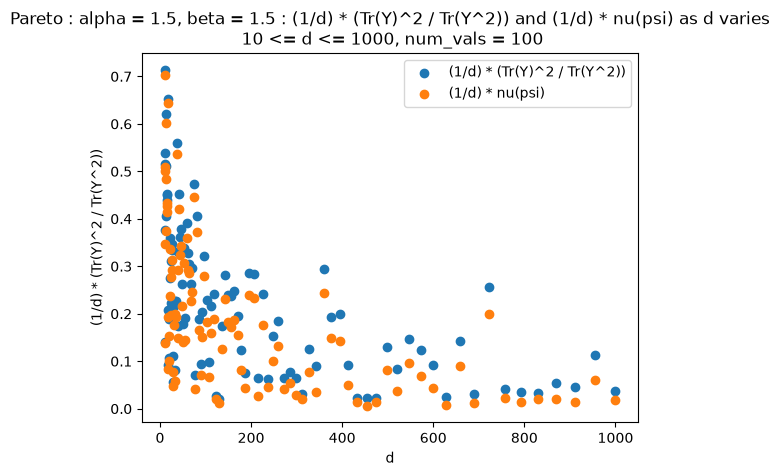

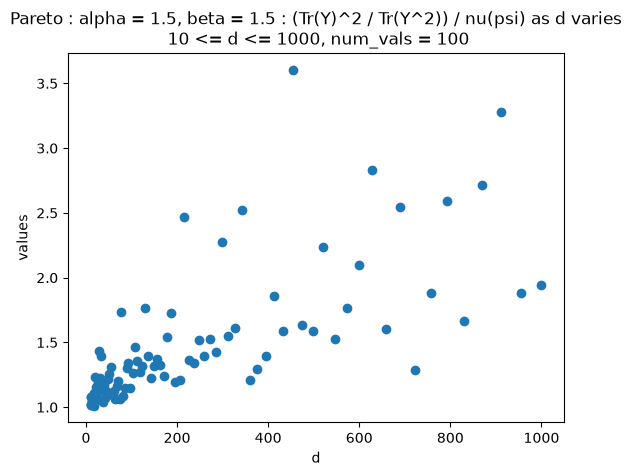

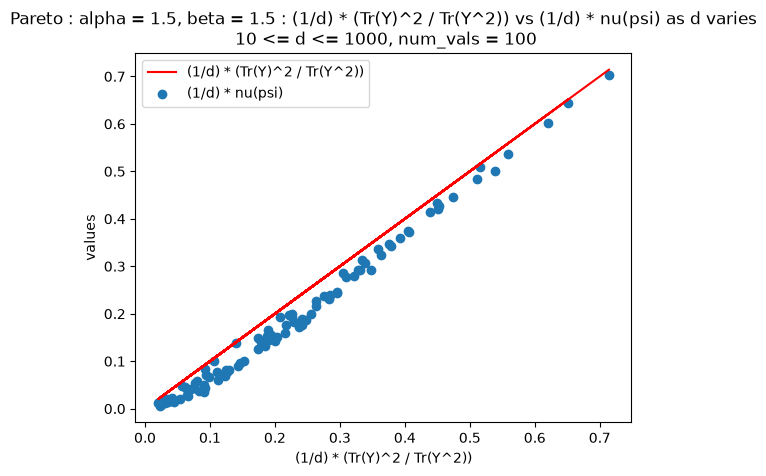

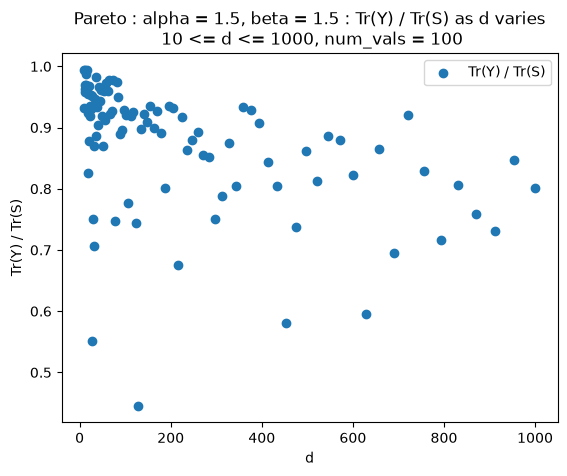

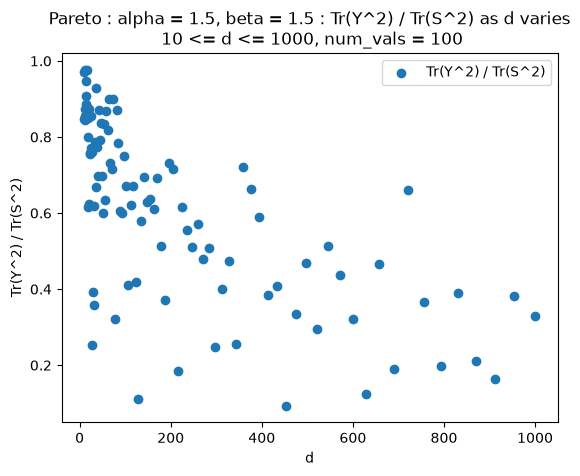

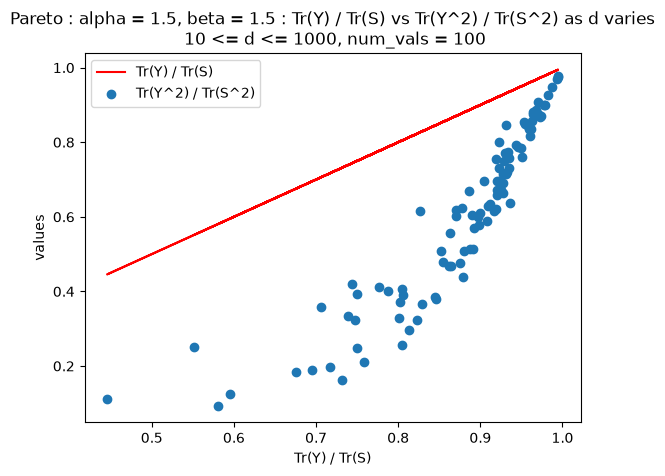

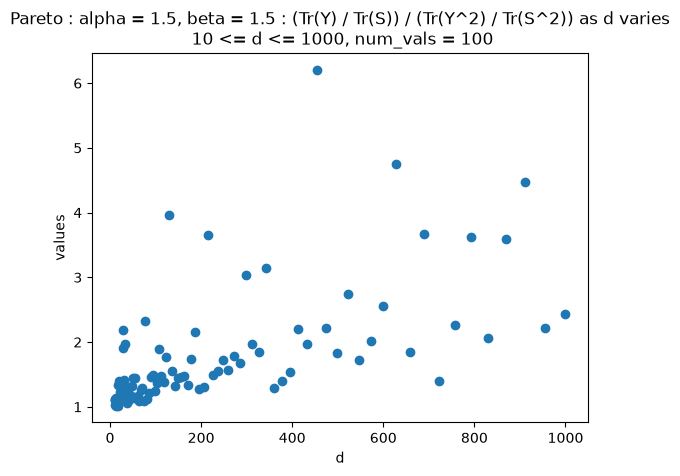

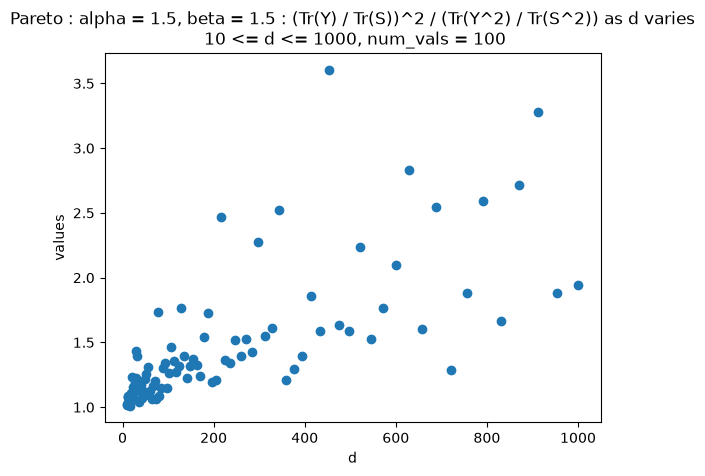

In [11]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

# More Pareto

In [12]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 1000
max_d = 2000
num_steps = 10
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 1.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (1000, 1000)
Q.shape =  (1000, 1000)
B.shape =  (1000, 1000)
Qt.shape =  (1000, 1000)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (1080, 1080)
Q.shape =  (1080, 1080)
B.shape =  (1080, 1080)
Qt.shape =  (1080, 1080)
** calculate_nu_cpu

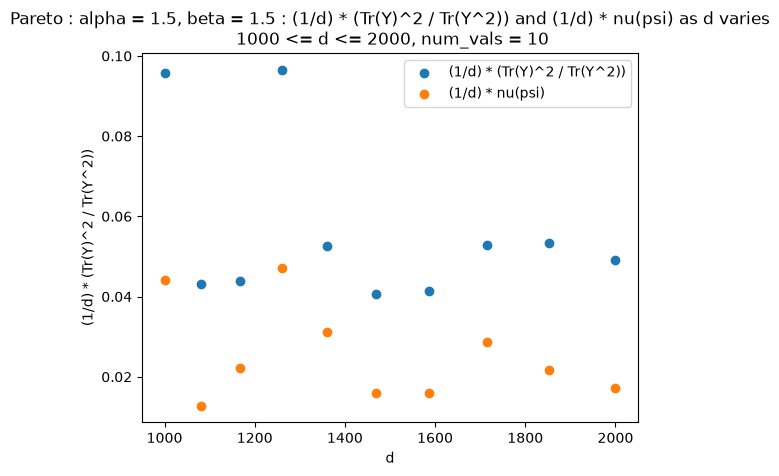

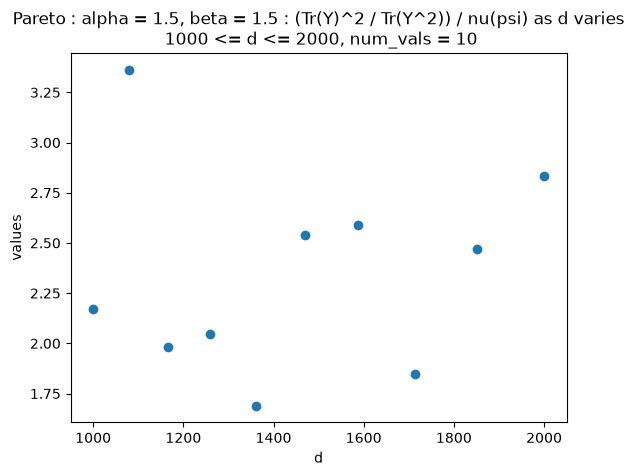

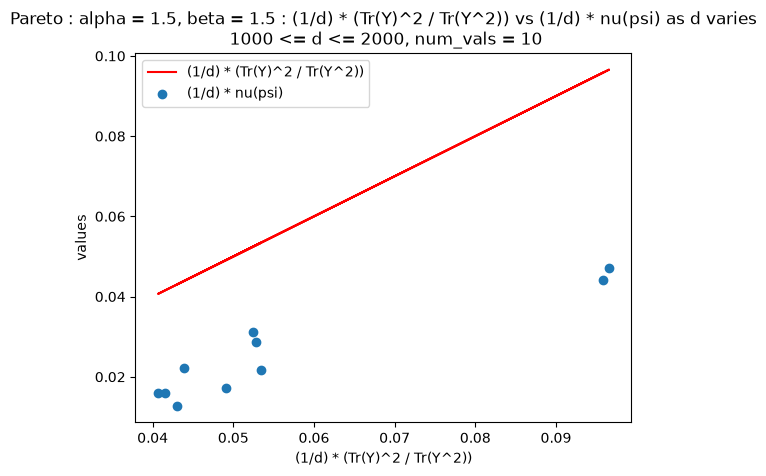

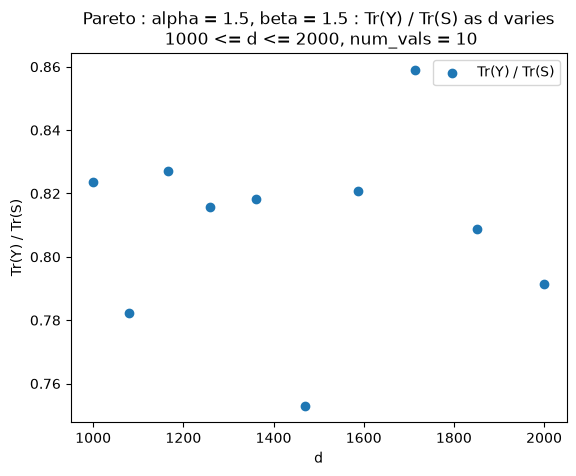

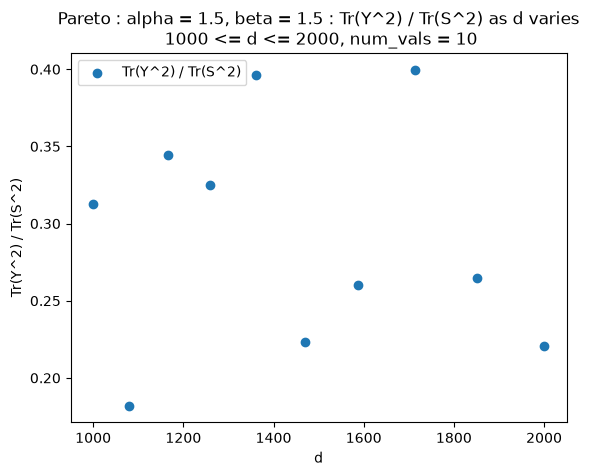

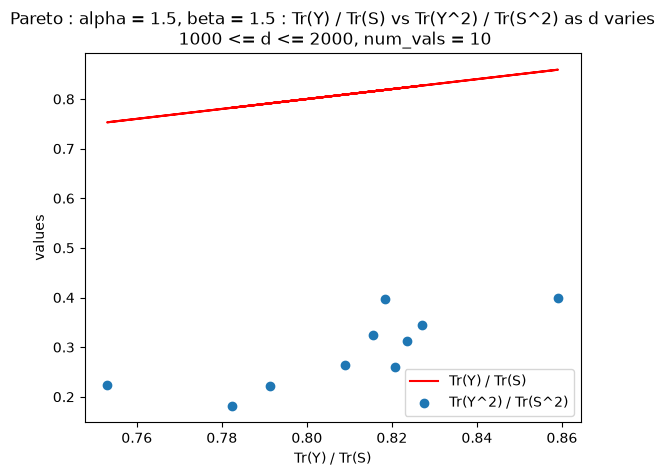

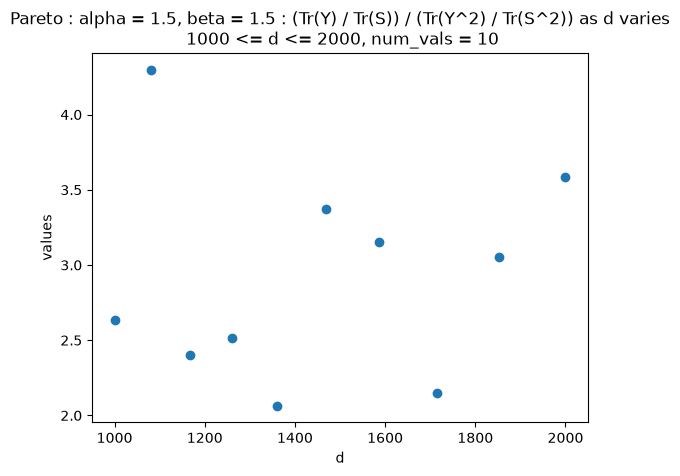

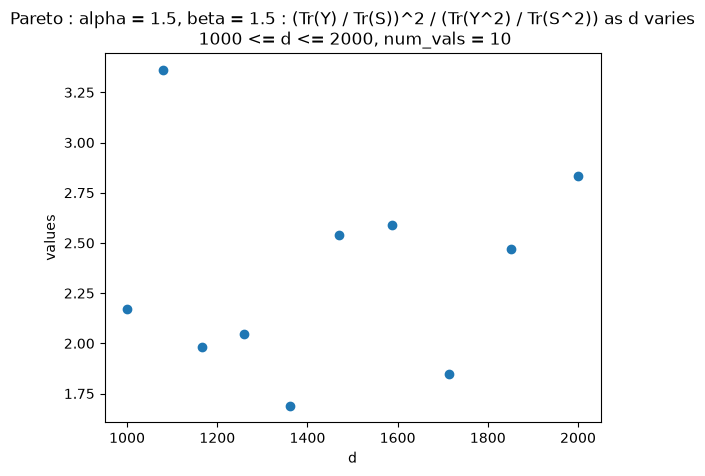

In [13]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [14]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 50
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 1.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (100, 100)
Q.shape =  (100, 100)
B.shape =  (100, 100)
Qt.shape =  (100, 100)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 2000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 0.5
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.5
B_beta = 5.0
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 1000
num_steps = 100
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 2.1
B_beta = 2.1
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

In [ ]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

min_d = 100
max_d = 2000
num_steps = 50
d_vals = min_d * np.exp(math.log(max_d / min_d) * np.linspace(0, 1, num=num_steps))
this_config["d_vals"] = d_vals

A_alpha = 0.1
B_beta = 0.1
this_config["A_pareto_alpha_vals"] = A_alpha * np.ones(len(d_vals))
this_config["B_pareto_beta_vals"] = B_beta * np.ones(len(d_vals))

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
pp.plot_one(xx, this_prefix)

# Now fix d, and take alpha = beta, varying between 0.1 and 5.0

In [12]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.1,3.5,0.02)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64
 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9  0.92
 0.94 0.96 0.98 1.   1.02 1.04 1.06 1.08 1.1  1.12 1.14 1.16 1.18 1.2
 1.22 1.24 1.26 1.28 1.3  1.32 1.34 1.36 1.38 1.4  1.42 1.44 1.46 1.48
 1.5  1.52 1.54 1.56 1.58 1.6  1.62 1.64 1.66 1.68 1.7  1.72 1.74 1.76
 1.78 1.8  1.82 1.84 1.86 1.88 1.9  1.92 1.94 1.96 1.98 2.   2.02 2.04
 2.06 2.08 2.1  2.12 2.14 2.16 2.18 2.2  2.22 2.24 2.26 2.28 2.3  2.32
 2.34 2.36 2.38 2.4  2.42 2.44 2.46 2.48 2.5  2.52 2.54 2.56 2.58 2.6
 2.62 

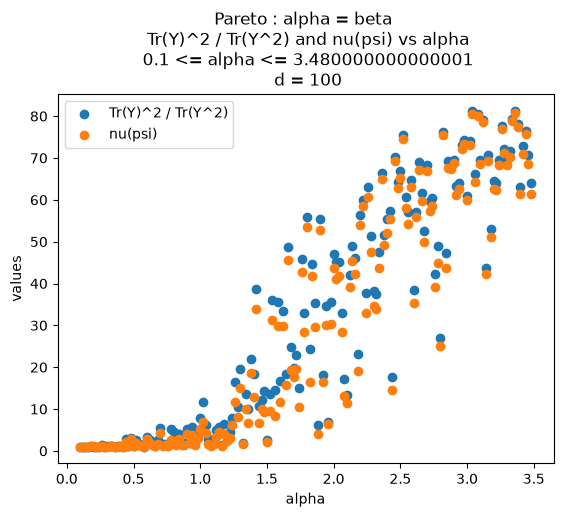

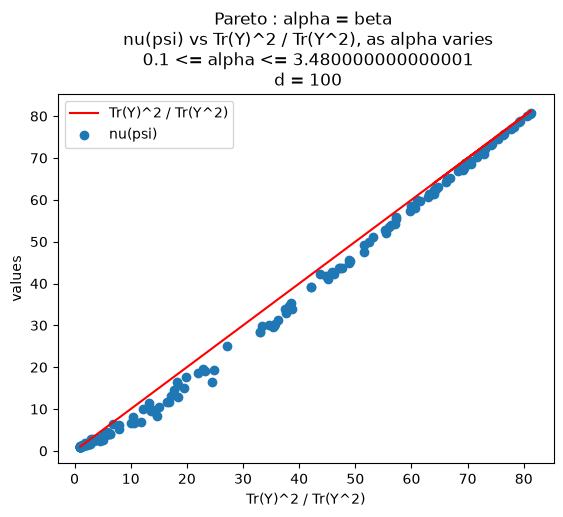

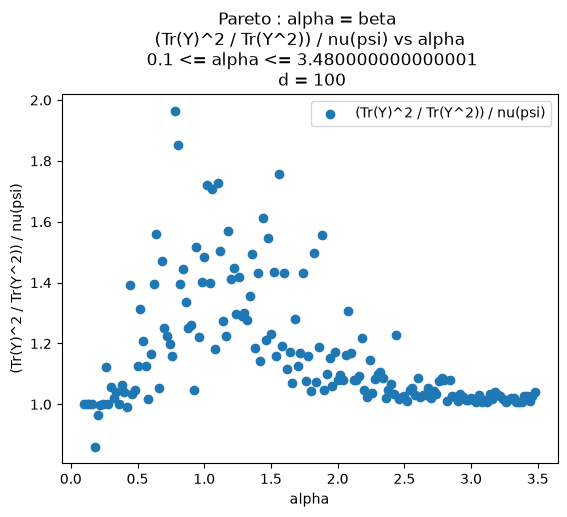

In [33]:
this_prefix = "Pareto : alpha = beta \n"
plot_two(xx, this_prefix)

# again, with larger d and finer resolution

In [14]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.5,1.01,0.01)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 500
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_500_05_10_001 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (500, 500)
Q.shape =  (500, 500)
B

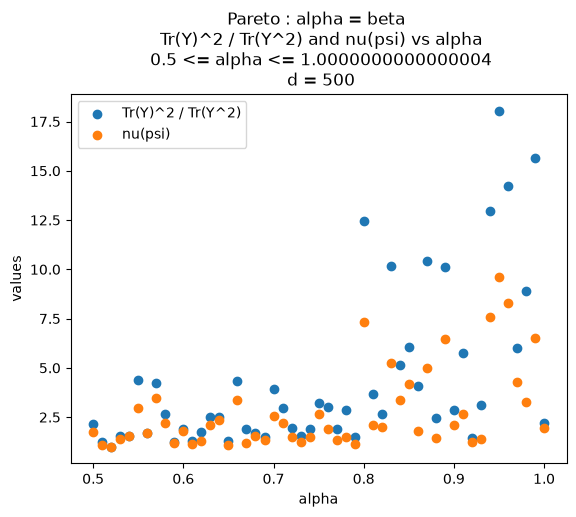

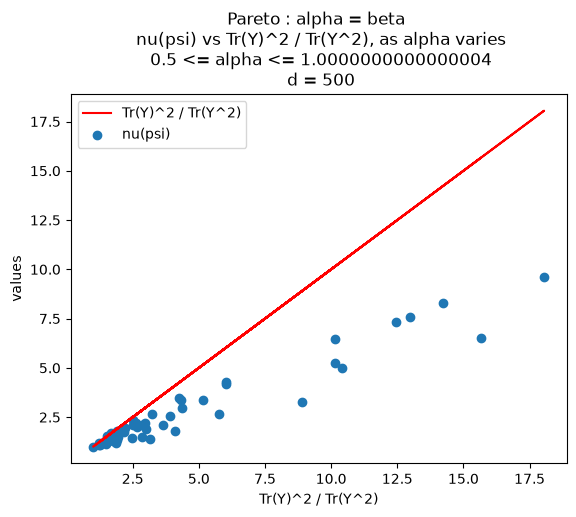

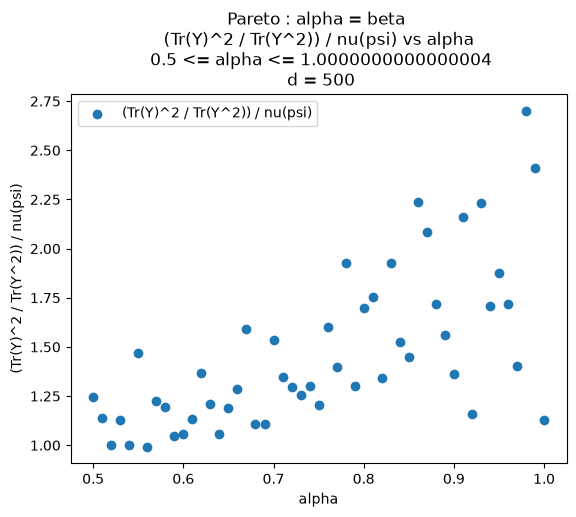

In [32]:
this_prefix = "Pareto : alpha = beta \n"
plot_two(xx_500_05_10_001, this_prefix)

In [16]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.9,1.11,0.01)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 1000
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_1000_09_11_001 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03
 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11]
[0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03
 1.04 1.05 1.06 1.07 1.08 1.09 1.1  1.11]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (1000, 1000)
Q.shape =  (1000, 1000)
B.shape =  (1000, 1000)
Qt.shape =  (1000, 1000)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
generating A
A is diagonal
A is Pareto
generating B


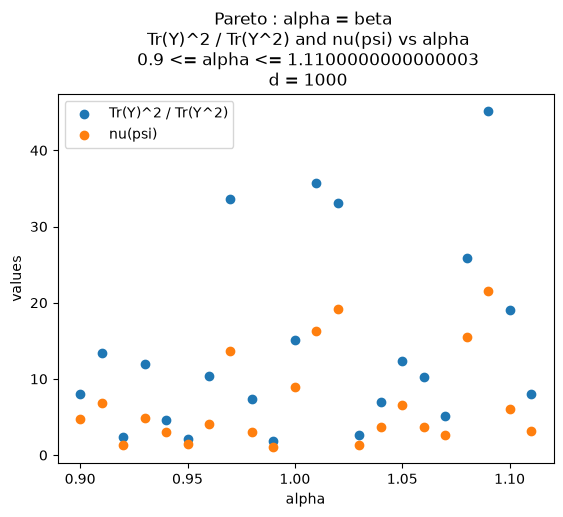

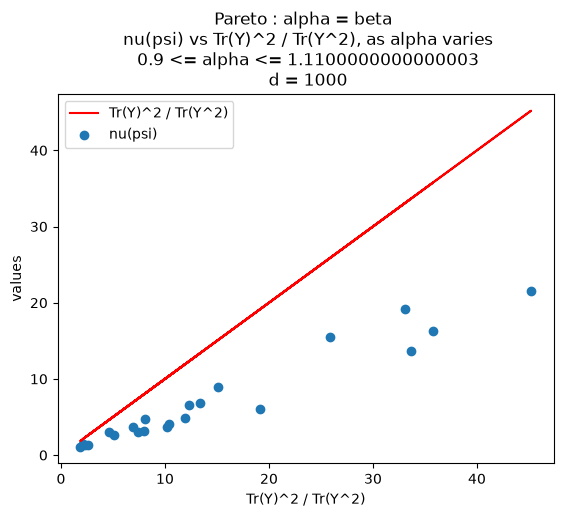

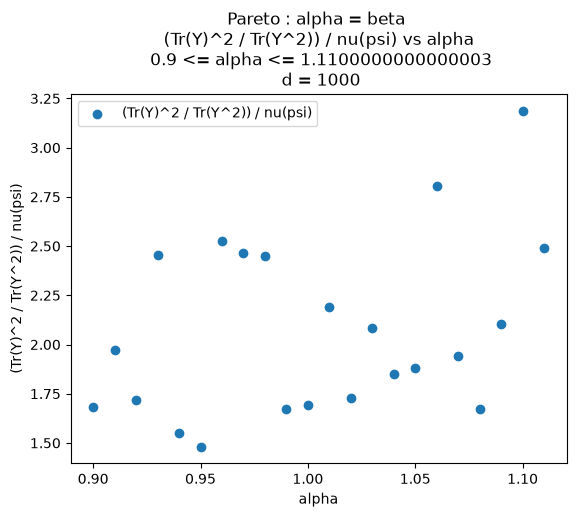

In [31]:
this_prefix = "Pareto : alpha = beta \n"
plot_two(xx_1000_09_11_001, this_prefix)

In [28]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.8,1.52,0.02)
this_config["B_pareto_beta_vals"] = this_config["A_pareto_alpha_vals"]

fixed_d = 500
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_500_08_15_002 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.8  0.82 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.   1.02 1.04 1.06
 1.08 1.1  1.12 1.14 1.16 1.18 1.2  1.22 1.24 1.26 1.28 1.3  1.32 1.34
 1.36 1.38 1.4  1.42 1.44 1.46 1.48 1.5 ]
[0.8  0.82 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.   1.02 1.04 1.06
 1.08 1.1  1.12 1.14 1.16 1.18 1.2  1.22 1.24 1.26 1.28 1.3  1.32 1.34
 1.36 1.38 1.4  1.42 1.44 1.46 1.48 1.5 ]
generating A
A is diagonal
A is Pareto
generating B
B is diagonal
B is Pareto
A.shape =  (500, 500)
Q.shape =  (500, 500)
B.shape =  (500, 500)
Qt.shape =  (500, 500)
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running on CPU
** calculate_nu_cpu ** running o

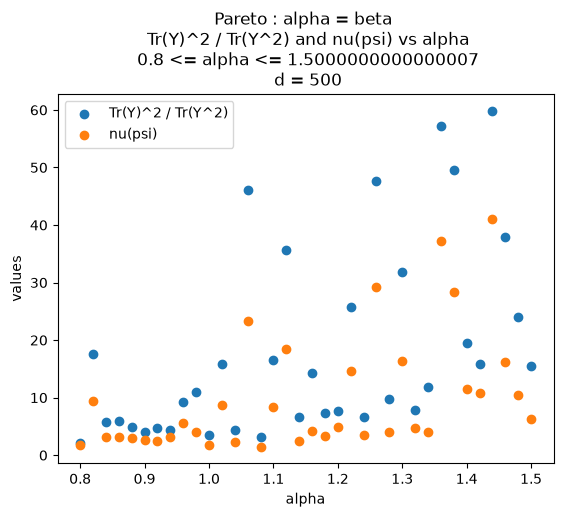

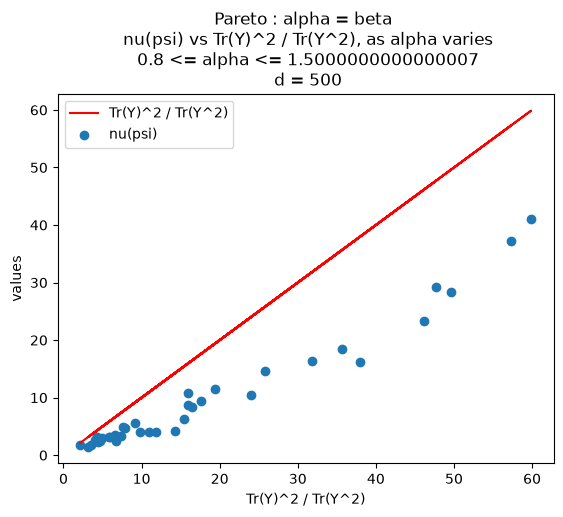

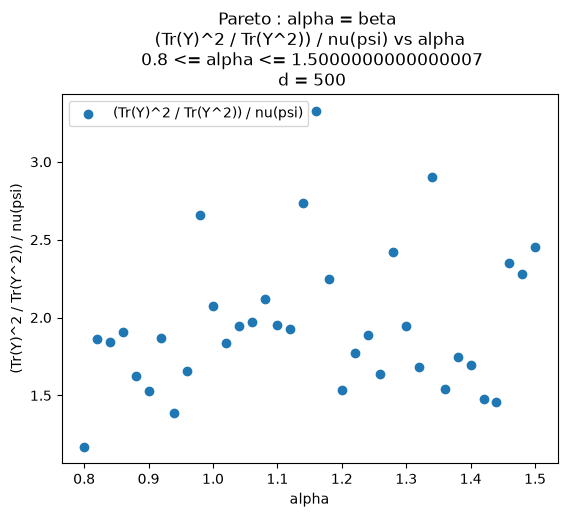

In [30]:
this_prefix = "Pareto : alpha = beta \n"
plot_two(xx_500_08_15_002, this_prefix)

In [34]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

this_config["A_pareto_alpha_vals"] = np.arange(0.1,2.0,0.01)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_100_01_20_001 = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23
 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37
 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51
 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65
 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79
 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93
 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07
 1.08 1.09 1.1  1.11 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2  1.21
 1.22 1.23 1.24 1.25 1.26 1.27 1.28 1.29 1.3  1.31 1.32 1.33 1.34 1.35
 1.3

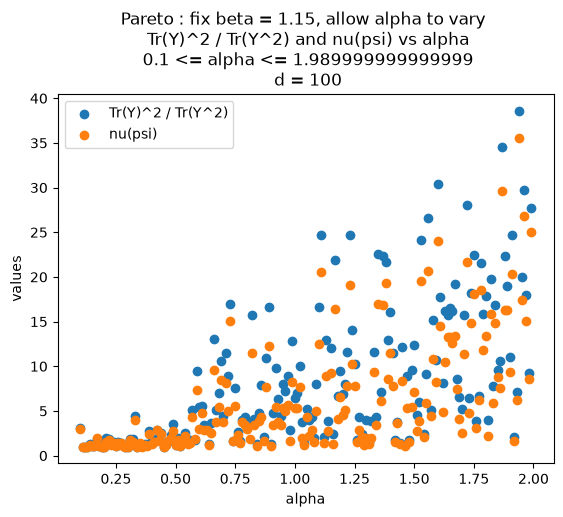

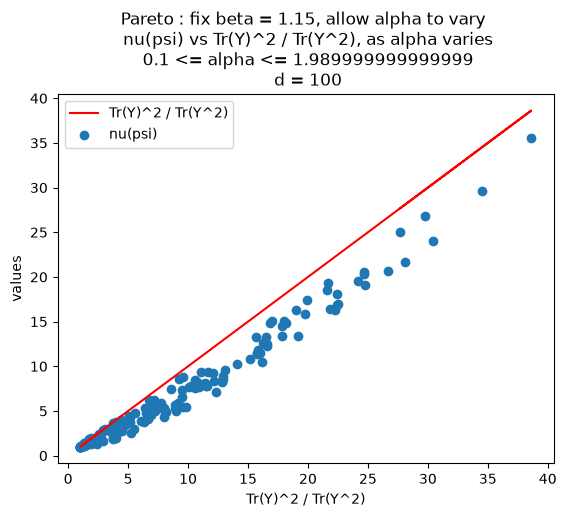

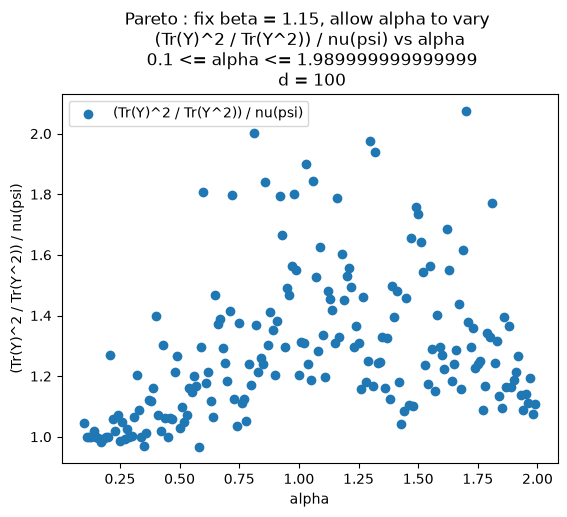

In [35]:
this_prefix = "Pareto : fix beta = 1.15, allow alpha to vary \n"
plot_two(xx_100_01_20_001, this_prefix)

# Fix alpha = beta = 1.15, and d = 100. Calculate 500 values, plot histogram

In [37]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

num_alpha_vals = 500
this_config["A_pareto_alpha_vals"] = 1.15 * np.ones(num_alpha_vals)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_100_115_500_times = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.1

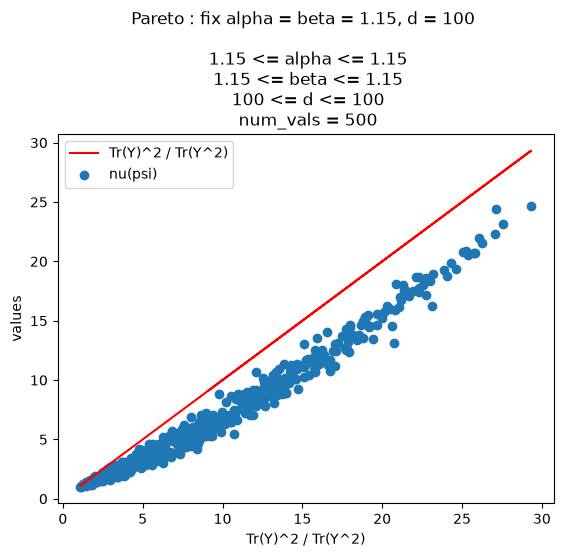


 Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi) 

shape : (500,)
min : 1.0431004563508608
max : 2.0947700681159604
sum : 710.3805965044266
mean : 1.4207611930088533
std : 0.1974171606054487
norm : 32.074412721525064
summary stats for input values
type : <class 'numpy.ndarray'>
shape : (500,)
min : 1.0431004563508608
max : 2.0947700681159604
mean : 1.4207
std : 0.1974
Histogram counts: [ 0  0  0  0  0  0  0  0  0  0  2  2  4  0  5  3  4  3 10  5  6 11  5 17
 14 19 10 18 12 15 18 11  8 14 11 12 13 12 19 10 18 12  9  7  9  6  9 12
 10  5  8  6  6  9  6  9  6  4  1  7  3  1  4  6  2  2  1  2  5  3  3  3
  1  2  1  1  0  2  1  1  1  0  1  1  0  0  0  0  0  0  1  0  0  0  0  0
  0  0  0  0]


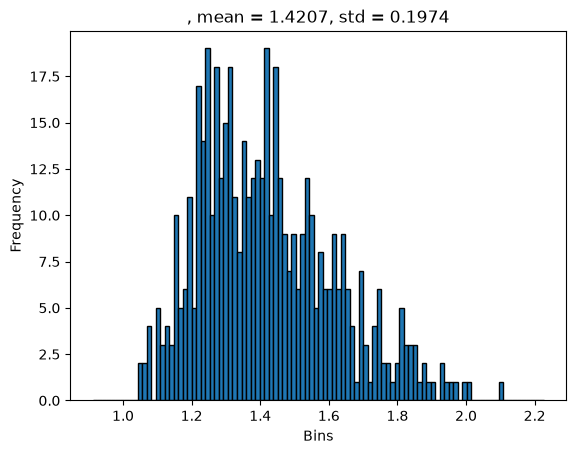

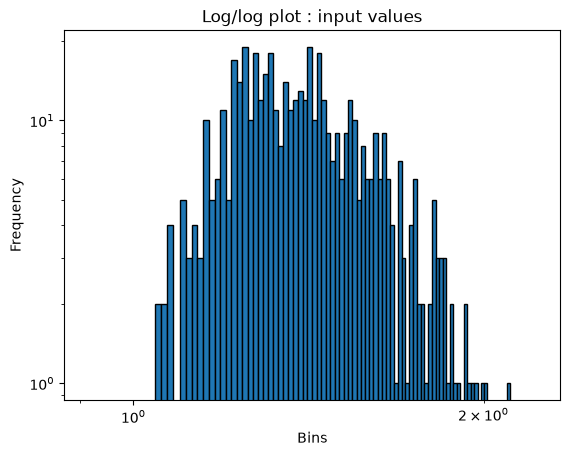

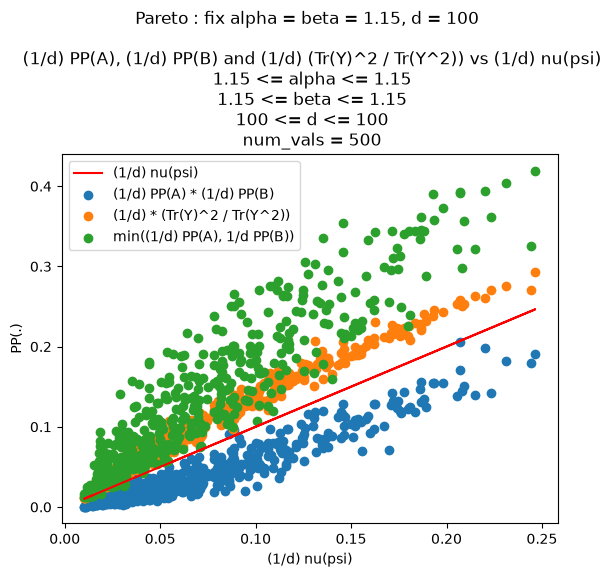

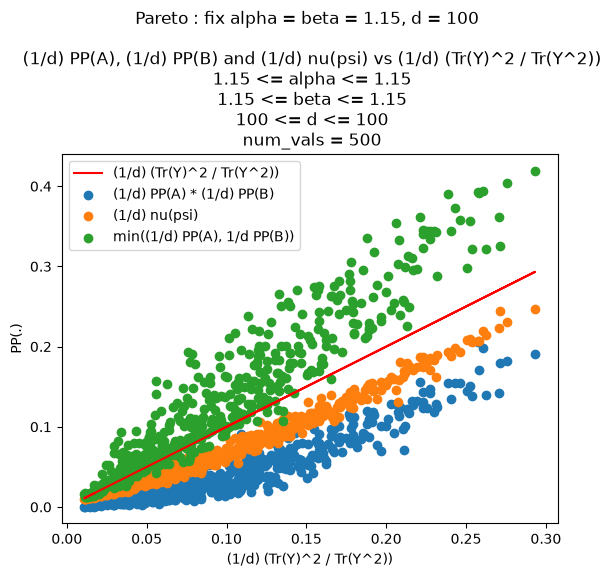

In [59]:
this_prefix = "Pareto : fix alpha = beta = 1.15, d = 100 \n"
plot_three(xx_100_115_500_times, this_prefix)

# Fix alpha = beta = 1.15, and d = 500. Calculate 200 values, plot histogram

In [46]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

num_alpha_vals = 200
this_config["A_pareto_alpha_vals"] = 1.15 * np.ones(num_alpha_vals)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 500
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_500_115_200_times = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.1

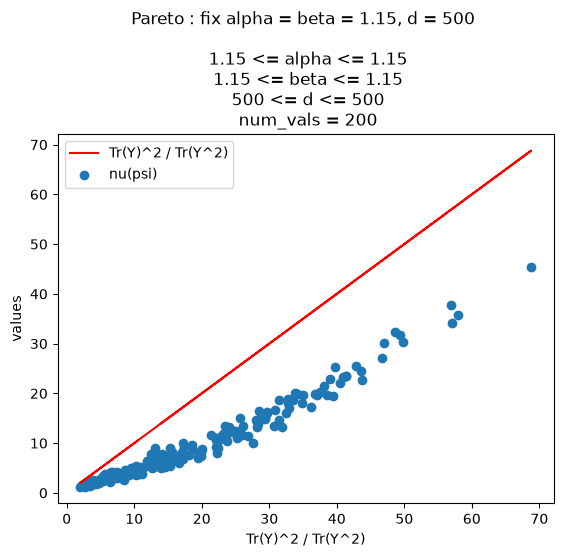


 Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi) 

shape : (200,)
min : 1.369162198720609
max : 3.177394951625727
sum : 408.30076045545235
mean : 2.0415038022772616
std : 0.3663073104426978
norm : 29.332298990690383
summary stats for input values
type : <class 'numpy.ndarray'>
shape : (200,)
min : 1.369162198720609
max : 3.177394951625727
mean : 2.0415
std : 0.3663
Histogram counts: [0 0 0 0 0 0 0 0 0 0 2 0 0 3 1 2 5 1 5 2 2 3 1 5 3 6 2 6 5 8 5 6 7 0 9 8 4
 6 5 3 2 5 3 2 4 3 4 2 4 2 8 2 1 3 2 3 5 2 1 2 4 2 1 2 1 0 1 0 1 0 1 1 3 3
 0 0 2 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


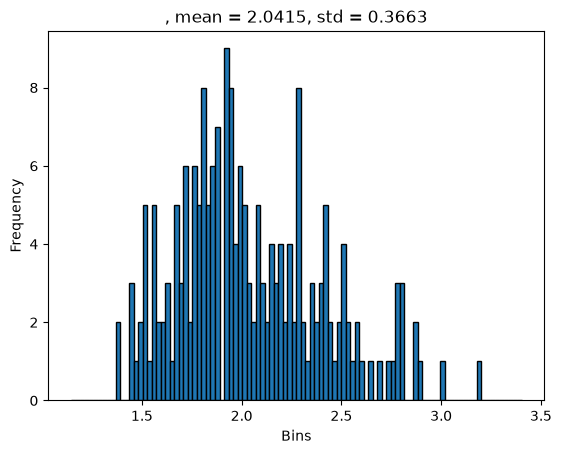

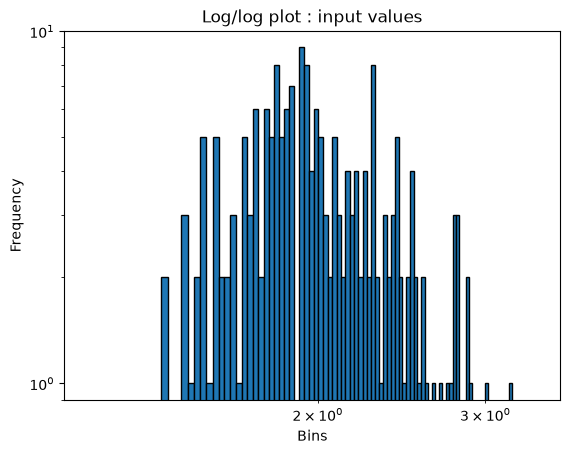

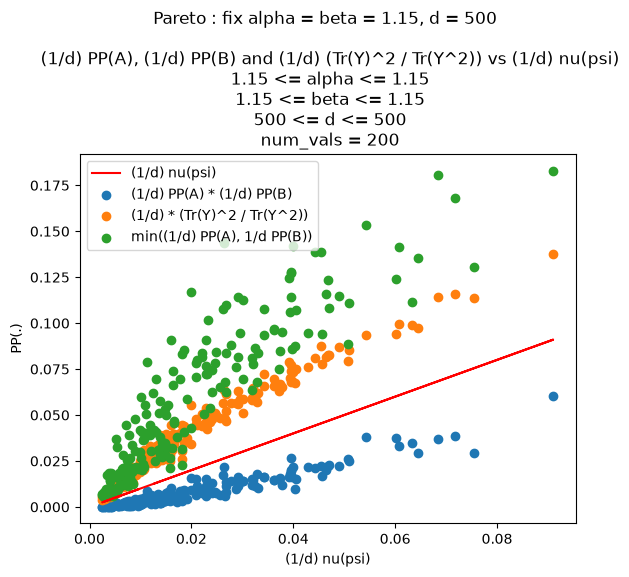

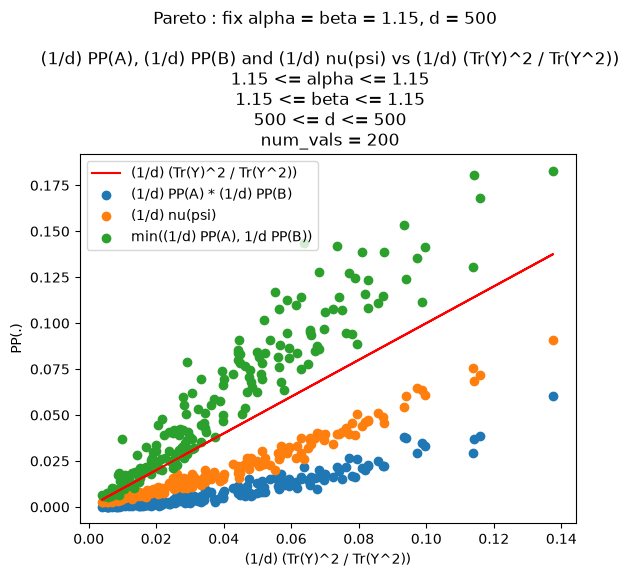

In [58]:
this_prefix = "Pareto : fix alpha = beta = 1.15, d = 500 \n"
plot_three(xx_500_115_200_times, this_prefix)

# Fix alpha = beta = 1.15, and d = 1000. Calculate 100 values, plot histogram

In [60]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

num_alpha_vals = 100
this_config["A_pareto_alpha_vals"] = 1.15 * np.ones(num_alpha_vals)
this_config["B_pareto_beta_vals"] = 1.15 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 1000
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_1000_115_100_times = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15]
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.

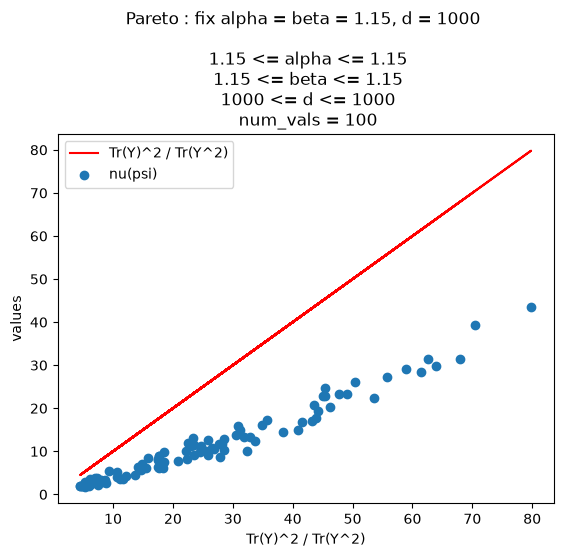


 Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi) 

shape : (100,)
min : 1.6904884062123944
max : 3.5836671221718612
sum : 236.26220729815307
mean : 2.3626220729815306
std : 0.40333927193713837
norm : 23.968032101168266
summary stats for input values
type : <class 'numpy.ndarray'>
shape : (100,)
min : 1.6904884062123944
max : 3.5836671221718612
mean : 2.3626
std : 0.4033
Histogram counts: [0 0 0 0 0 0 0 0 0 0 1 1 0 1 3 0 3 0 3 1 2 2 4 0 3 5 2 3 1 2 3 2 2 2 2 1 1
 0 2 4 3 1 1 4 4 1 5 2 0 2 0 1 0 1 3 1 1 0 1 1 0 2 1 1 1 0 2 0 0 0 0 0 0 1
 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


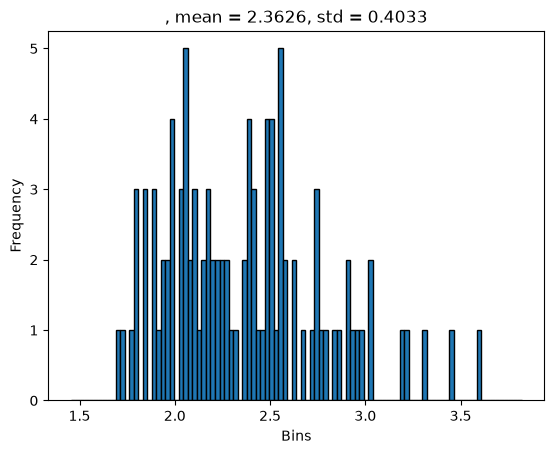

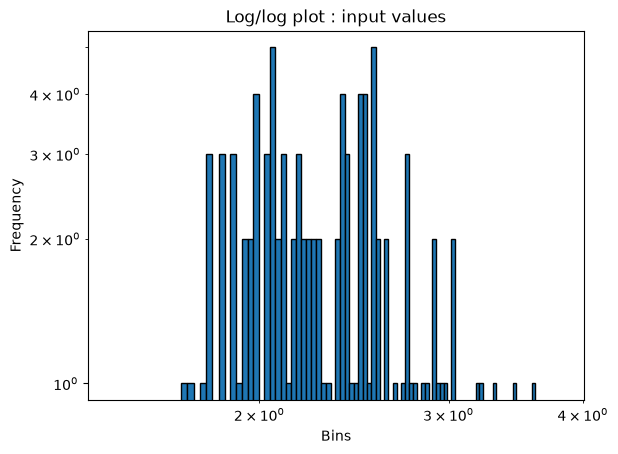

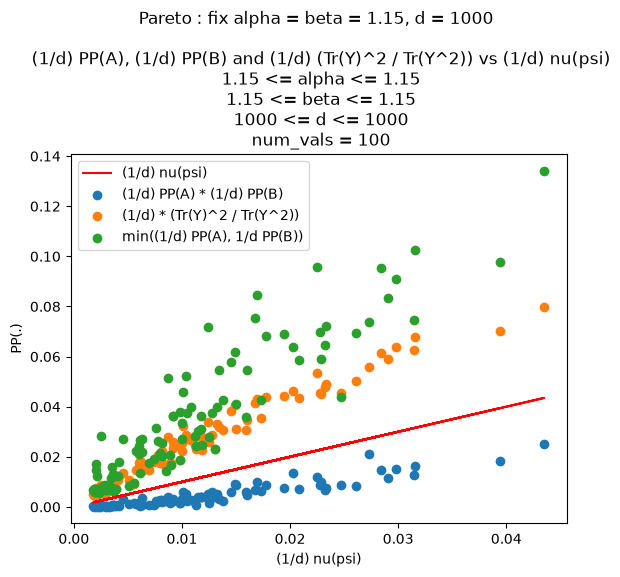

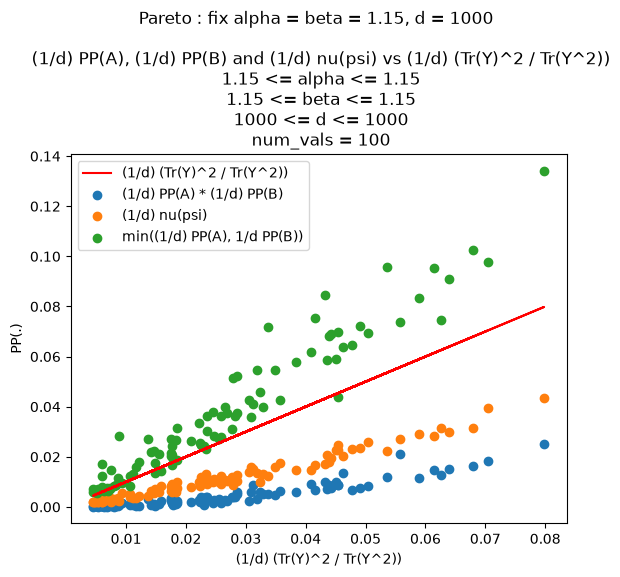

In [61]:
this_prefix = "Pareto : fix alpha = beta = 1.15, d = 1000 \n"
plot_three(xx_1000_115_100_times, this_prefix)

# Fix alpha = 1.15, beta = 5.0, and d = 100. Calculate 500 values, plot histogram

In [44]:
this_config = pp.get_default_config()
print(this_config)
this_config["verbose"] = True

this_config["y_equals_AQBQt"] = True
this_config["A_diagonal"] = True
this_config["A_pareto"] = True
this_config["B_diagonal"] = True
this_config["B_pareto"] = True

num_alpha_vals = 500
this_config["A_pareto_alpha_vals"] = 1.15 * np.ones(num_alpha_vals)
this_config["B_pareto_beta_vals"] = 5.0 * np.ones(len(this_config["A_pareto_alpha_vals"]))

fixed_d = 100
d_vals = fixed_d * np.ones(len(this_config["A_pareto_alpha_vals"]))
this_config["d_vals"] = d_vals

xx_100_115_50_500_times = pp.run_grand_unified_experiment_Y_eq_AQBQt(this_config)

{'d_vals': array([1.]), 'y_equals_AQBQt': False, 'y_equals_AQB': False, 'y_equals_AQ': False, 'A_diagonal': False, 'B_diagonal': False, 'A_pareto': False, 'A_pareto_alpha_vals': array([1.]), 'A_cauchy': False, 'A_uniform': False, 'B_pareto': False, 'B_pareto_beta_vals': array([1.]), 'B_cauchy': False, 'B_uniform': False, 'verbose': False}
verbose =  True
[1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15 1.15
 1.1

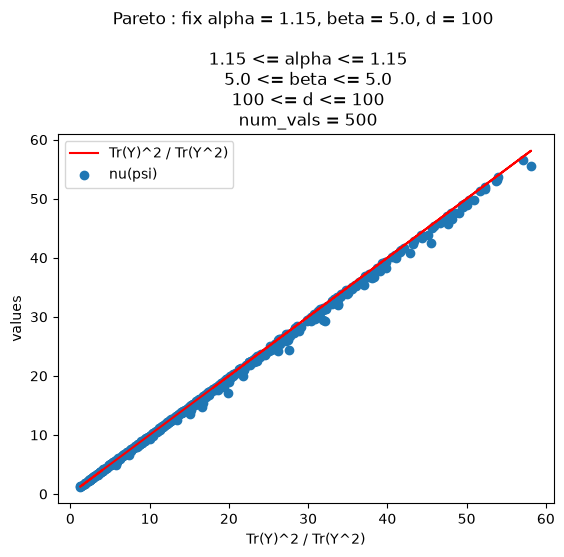


 Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi) 

shape : (500,)
min : 1.0007215223512447
max : 1.1806233535146802
sum : 511.36759685028704
mean : 1.0227351937005742
std : 0.019774214234715336
norm : 22.873328310308835
summary stats for input values
type : <class 'numpy.ndarray'>
shape : (500,)
min : 1.0007215223512447
max : 1.1806233535146802
mean : 1.0227
std : 0.0197
Histogram counts: [ 0  0  0  0  0  0  0  0  0  0 10 10 19 43 40 51 51 59 37 28 17 18 12 14
 12 10 15  5  3  7  4  4  4  4  2  0  1  1  0  0  2  2  3  0  0  2  1  1
  0  0  0  1  0  1  0  0  0  1  0  0  0  0  0  0  0  0  1  1  0  1  0  0
  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
  0  0  0  0]


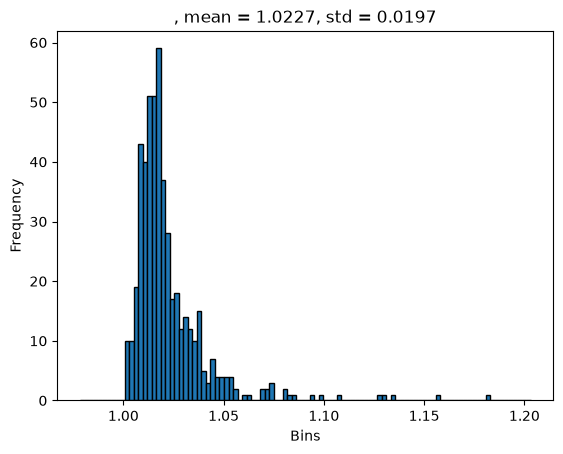

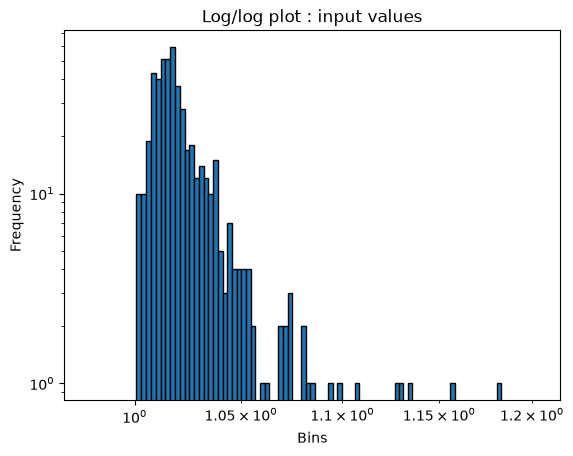

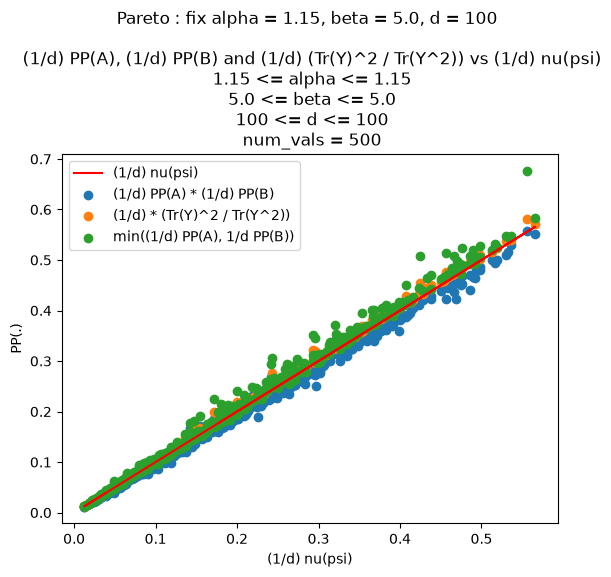

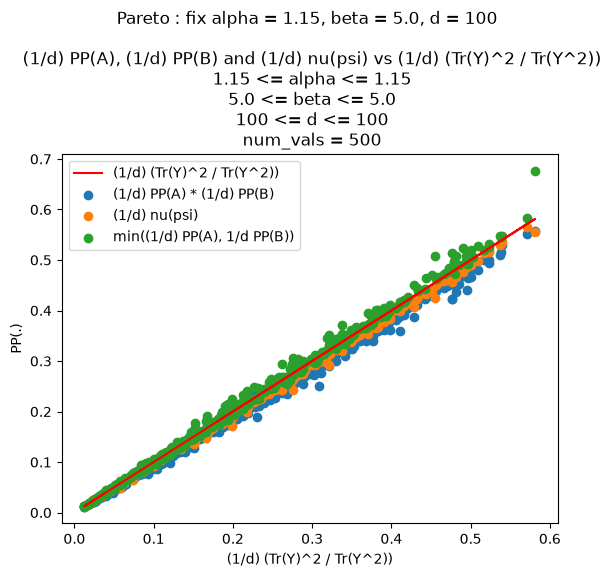

In [57]:
this_prefix = "Pareto : fix alpha = 1.15, beta = 5.0, d = 100 \n"
plot_three(xx_100_115_50_500_times, this_prefix)

In [ ]:
this_prefix = "Pareto : alpha = " + str(A_alpha) + ", beta = " + str(B_beta)
plot_one(xx, this_prefix)

In [24]:
def plot_two(results_dict : dict, prefix : str):
    
    # produce plots for run_grand_unified_experiment_Y_eq_AQBQt

    d_vals = results_dict["d_vals"]
    A_pareto_alpha_vals = results_dict["A_pareto_alpha_vals"]
    B_pareto_beta_vals = results_dict["B_pareto_beta_vals"]
    trace_S_vals = results_dict["trace_S_vals"]
    trace_Ssquared_vals = results_dict["trace_Ssquared_vals"]
    nu_psi_vals = results_dict["nu_psi_vals"]
    nu_psi_over_d_vals = results_dict["nu_psi_over_d_vals"]
    trace_Y_vals = results_dict["trace_Y_vals"]
    trace_Ysquared_vals = results_dict["trace_Ysquared_vals"]
    trace_Y_all_squared_over_trace_Ysquared_vals = results_dict["trace_Y_all_squared_over_trace_Ysquared_vals"]
    trace_Y_all_squared_over_trace_Ysquared_over_d_vals = results_dict["trace_Y_all_squared_over_trace_Ysquared_over_d_vals"]
    trace_Y_over_trace_S_vals = results_dict["trace_Y_over_trace_S_vals"]
    trace_Ysquared_over_trace_Ssquared_vals = results_dict["trace_Ysquared_over_trace_Ssquared_vals"]    
    pp_dim_S_vals = results_dict["pp_dim_S_vals"]
    pp_dim_Y_vals = results_dict["pp_dim_Y_vals"]
    pp_dim_A_vals = results_dict["pp_dim_A_vals"]
    pp_dim_B_vals = results_dict["pp_dim_B_vals"]
    pp_dim_S_over_d_vals = results_dict["pp_dim_S_over_d_vals"]
    pp_dim_Y_over_d_vals = results_dict["pp_dim_Y_over_d_vals"]
    pp_dim_A_over_d_vals = results_dict["pp_dim_A_over_d_vals"]
    pp_dim_B_over_d_vals = results_dict["pp_dim_B_over_d_vals"]
    min_pp_dim_A_over_d_pp_dim_B_over_d_vals = results_dict["min_pp_dim_A_over_d_pp_dim_B_over_d_vals"]
    pp_dim_A_over_d_times_pp_dim_B_over_d_vals = results_dict["pp_dim_A_over_d_times_pp_dim_B_over_d_vals"]
    
    min_d = int(np.min(d_vals))
    max_d = int(np.max(d_vals))

    min_alpha = np.min(A_pareto_alpha_vals)
    max_alpha = np.max(A_pareto_alpha_vals)

    generic_title_one = "\n " + str(min_alpha) + " <= alpha <= " + str(max_alpha)
    generic_title_two = "\n d = " + str(min_d)

    this_title = prefix + " Tr(Y)^2 / Tr(Y^2) and nu(psi) vs alpha"
    this_title += generic_title_one
    this_title += generic_title_two
    plt.scatter(A_pareto_alpha_vals, trace_Y_all_squared_over_trace_Ysquared_vals, label = "Tr(Y)^2 / Tr(Y^2)")
    plt.scatter(A_pareto_alpha_vals, nu_psi_vals, label = "nu(psi)")
    plt.xlabel("alpha")
    plt.ylabel("values")
    plt.legend()
    plt.title(this_title)
    plt.show()

    this_title = prefix + " nu(psi) vs Tr(Y)^2 / Tr(Y^2), as alpha varies"
    this_title += generic_title_one
    this_title += generic_title_two
    plt.plot(trace_Y_all_squared_over_trace_Ysquared_vals, trace_Y_all_squared_over_trace_Ysquared_vals, 
             color = "red", label = "Tr(Y)^2 / Tr(Y^2)")
    plt.scatter(trace_Y_all_squared_over_trace_Ysquared_vals, nu_psi_vals, label = "nu(psi)")
    plt.xlabel("Tr(Y)^2 / Tr(Y^2)")
    plt.ylabel("values")
    plt.legend()
    plt.title(this_title)
    plt.show()

    this_title = prefix + "(Tr(Y)^2 / Tr(Y^2)) / nu(psi) vs alpha"
    this_title += generic_title_one
    this_title += generic_title_two
    plt.scatter(A_pareto_alpha_vals, trace_Y_all_squared_over_trace_Ysquared_vals / nu_psi_vals, 
                label = "(Tr(Y)^2 / Tr(Y^2)) / nu(psi)")
    plt.xlabel("alpha")
    plt.ylabel("(Tr(Y)^2 / Tr(Y^2)) / nu(psi)")
    plt.legend()
    plt.title(this_title)
    plt.show()

    

In [56]:
def plot_three(results_dict : dict, prefix : str):
    
    # produce plots for run_grand_unified_experiment_Y_eq_AQBQt
    # plot histograms

    d_vals = results_dict["d_vals"]
    A_pareto_alpha_vals = results_dict["A_pareto_alpha_vals"]
    B_pareto_beta_vals = results_dict["B_pareto_beta_vals"]
    trace_S_vals = results_dict["trace_S_vals"]
    trace_Ssquared_vals = results_dict["trace_Ssquared_vals"]
    nu_psi_vals = results_dict["nu_psi_vals"]
    nu_psi_over_d_vals = results_dict["nu_psi_over_d_vals"]
    trace_Y_vals = results_dict["trace_Y_vals"]
    trace_Ysquared_vals = results_dict["trace_Ysquared_vals"]
    trace_Y_all_squared_over_trace_Ysquared_vals = results_dict["trace_Y_all_squared_over_trace_Ysquared_vals"]
    trace_Y_all_squared_over_trace_Ysquared_over_d_vals = results_dict["trace_Y_all_squared_over_trace_Ysquared_over_d_vals"]
    trace_Y_over_trace_S_vals = results_dict["trace_Y_over_trace_S_vals"]
    trace_Ysquared_over_trace_Ssquared_vals = results_dict["trace_Ysquared_over_trace_Ssquared_vals"]    
    pp_dim_S_vals = results_dict["pp_dim_S_vals"]
    pp_dim_Y_vals = results_dict["pp_dim_Y_vals"]
    pp_dim_A_vals = results_dict["pp_dim_A_vals"]
    pp_dim_B_vals = results_dict["pp_dim_B_vals"]
    pp_dim_S_over_d_vals = results_dict["pp_dim_S_over_d_vals"]
    pp_dim_Y_over_d_vals = results_dict["pp_dim_Y_over_d_vals"]
    pp_dim_A_over_d_vals = results_dict["pp_dim_A_over_d_vals"]
    pp_dim_B_over_d_vals = results_dict["pp_dim_B_over_d_vals"]
    min_pp_dim_A_over_d_pp_dim_B_over_d_vals = results_dict["min_pp_dim_A_over_d_pp_dim_B_over_d_vals"]
    pp_dim_A_over_d_times_pp_dim_B_over_d_vals = results_dict["pp_dim_A_over_d_times_pp_dim_B_over_d_vals"]
    
    min_d = int(np.min(d_vals))
    max_d = int(np.max(d_vals))

    min_alpha = np.min(A_pareto_alpha_vals)
    max_alpha = np.max(A_pareto_alpha_vals)

    min_beta = np.min(B_pareto_beta_vals)
    max_beta = np.max(B_pareto_beta_vals)

    this_title = prefix
    this_title += "\n " + str(min_alpha) + " <= alpha <= " + str(max_alpha)
    this_title += "\n " + str(min_beta) + " <= beta <= " + str(max_beta)
    this_title += "\n " + str(min_d) + " <= d <= " + str(max_d)
    this_title += "\n num_vals = " + str(len(d_vals))
    plt.plot(trace_Y_all_squared_over_trace_Ysquared_vals, 
             trace_Y_all_squared_over_trace_Ysquared_vals, color = "red", label = "Tr(Y)^2 / Tr(Y^2)")
    plt.scatter(trace_Y_all_squared_over_trace_Ysquared_vals, nu_psi_vals, label = "nu(psi)")
    plt.xlabel("Tr(Y)^2 / Tr(Y^2)")
    plt.ylabel("values")
    plt.legend()
    plt.title(this_title)
    plt.show()

    ratio_vals = trace_Y_all_squared_over_trace_Ysquared_vals / nu_psi_vals

    sep = "\n=======================================\n"
    print(sep, "Statistics for (Tr(Y)^2 / Tr(Y^2)) / nu(psi)", sep)
    pp.display_stats(ratio_vals)
    pp.plot_histogram_of_values(ratio_vals)

    this_title = prefix
    this_title += "\n (1/d) PP(A), (1/d) PP(B) and (1/d) (Tr(Y)^2 / Tr(Y^2)) vs (1/d) nu(psi)"
    this_title += "\n " + str(min_alpha) + " <= alpha <= " + str(max_alpha)
    this_title += "\n " + str(min_beta) + " <= beta <= " + str(max_beta)
    this_title += "\n " + str(min_d) + " <= d <= " + str(max_d)
    this_title += "\n num_vals = " + str(len(d_vals))
    plt.plot(nu_psi_over_d_vals, nu_psi_over_d_vals, color = "red", label = "(1/d) nu(psi)")
    plt.scatter(nu_psi_over_d_vals, pp_dim_A_over_d_times_pp_dim_B_over_d_vals, label = "(1/d) PP(A) * (1/d) PP(B)")
    plt.scatter(nu_psi_over_d_vals, trace_Y_all_squared_over_trace_Ysquared_over_d_vals, 
                label = "(1/d) * (Tr(Y)^2 / Tr(Y^2))")
    plt.scatter(nu_psi_over_d_vals, min_pp_dim_A_over_d_pp_dim_B_over_d_vals, label = "min((1/d) PP(A), 1/d PP(B))")
    plt.xlabel("(1/d) nu(psi)")
    plt.ylabel("PP(.)")
    plt.legend()
    plt.title(this_title)
    plt.show()

    this_title = prefix
    this_title += "\n (1/d) PP(A), (1/d) PP(B) and (1/d) nu(psi) vs (1/d) (Tr(Y)^2 / Tr(Y^2))"
    this_title += "\n " + str(min_alpha) + " <= alpha <= " + str(max_alpha)
    this_title += "\n " + str(min_beta) + " <= beta <= " + str(max_beta)
    this_title += "\n " + str(min_d) + " <= d <= " + str(max_d)
    this_title += "\n num_vals = " + str(len(d_vals))
    plt.plot(trace_Y_all_squared_over_trace_Ysquared_over_d_vals, 
                trace_Y_all_squared_over_trace_Ysquared_over_d_vals, color = "red",
                label = "(1/d) (Tr(Y)^2 / Tr(Y^2))")
    plt.scatter(trace_Y_all_squared_over_trace_Ysquared_over_d_vals,
                pp_dim_A_over_d_times_pp_dim_B_over_d_vals, label = "(1/d) PP(A) * (1/d) PP(B)")
    plt.scatter(trace_Y_all_squared_over_trace_Ysquared_over_d_vals,
                nu_psi_over_d_vals, label = "(1/d) nu(psi)")
    plt.scatter(trace_Y_all_squared_over_trace_Ysquared_over_d_vals,
                min_pp_dim_A_over_d_pp_dim_B_over_d_vals, label = "min((1/d) PP(A), 1/d PP(B))")
    plt.xlabel("(1/d) (Tr(Y)^2 / Tr(Y^2))")
    plt.ylabel("PP(.)")
    plt.legend()
    plt.title(this_title)
    plt.show()
                
    
    